# Setup

In [1]:
import json
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
def compute_score_delta_v2(data1, data2):
    delta_total_1 = []
    delta_total_2 = []
    score_lookup = {}
    for item in data2:
        q_id = str(item.get("question_id")) 
        p_id = str(item.get("program_id"))
        score_val = item.get("code_gpt_score", {}).get("code_gpt_score", 0.0) 
        
        score_lookup[(q_id, p_id)] = score_val

    for d in data1:
        task_id = str(d.get("task_id"))
        
        grade_keys = [k for k in d.keys() if k.startswith("grade-")]
        
        for g_key in grade_keys:
            program_id = g_key.replace("grade-", "") 
            
            if (task_id, program_id) in score_lookup:
                exec_binary = d[g_key].get("execution", 0.0)
                exec_custom = d[g_key].get("execution_custom", 0.0)
                pred_score = score_lookup[(task_id, program_id)]
                if pred_score >= 0.0:
                    diff1 = abs(pred_score - exec_binary) * 4
                    diff2 = abs(pred_score - exec_custom) * 4
                    delta_total_1.append(diff1)
                    delta_total_2.append(diff2)

    return delta_total_1, delta_total_2

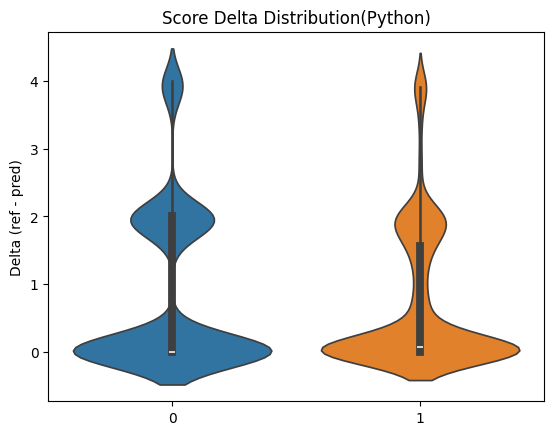

In [ ]:
with open(f"../data/humaneval-x/humaneval_python_grade_evalplus_ratio.json") as f:
    data1 = json.load(f)
with open(f"../codejudge_scripts/output/humaneval-x/python-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json") as f:
    data2 = json.load(f)

delta_total_1, delta_total_2 = compute_score_delta_v2(data1, data2["data"])

plt.figure()
sns.violinplot(data=[delta_total_1, delta_total_2])

plt.title("Score Delta Distribution(Python)")
plt.ylabel("Delta (ref - pred)")
plt.show()

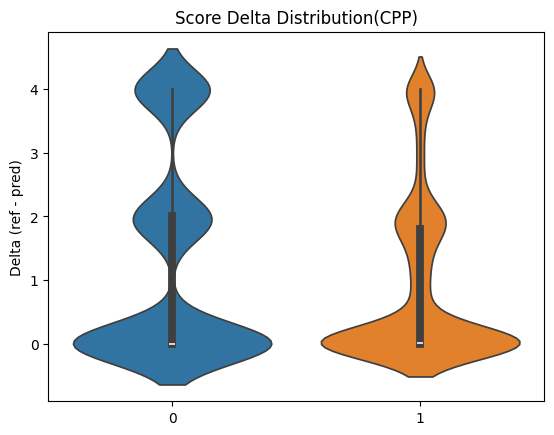

In [ ]:
with open(f"../data/humaneval-x/humaneval_cpp_grade_evalplus_ratio.json") as f:
    data1 = json.load(f)
with open(f"../codejudge_scripts/output/humaneval-x/cpp-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json") as f:
    data2 = json.load(f)

delta_total_1, delta_total_2 = compute_score_delta_v2(data1, data2["data"])

plt.figure()
sns.violinplot(data=[delta_total_1, delta_total_2])

plt.title("Score Delta Distribution(CPP)")
plt.ylabel("Delta (ref - pred)")
plt.show()

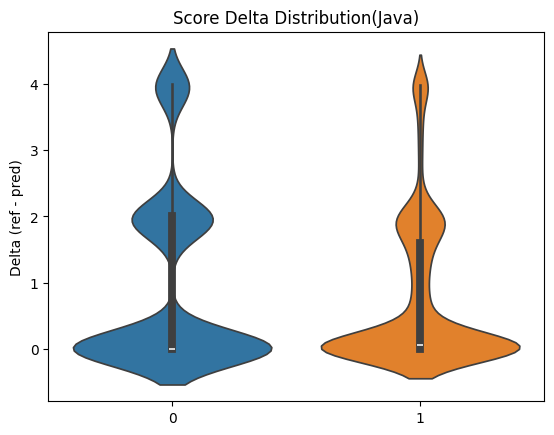

In [ ]:
with open(f"../data/humaneval-x/humaneval_java_grade_evalplus_ratio.json") as f:
    data1 = json.load(f)
with open(f"../codejudge_scripts/output/humaneval-x/java-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json") as f:
    data2 = json.load(f)

delta_total_1, delta_total_2 = compute_score_delta_v2(data1, data2["data"])

plt.figure()
sns.violinplot(data=[delta_total_1, delta_total_2])

plt.title("Score Delta Distribution(Java)")
plt.ylabel("Delta (ref - pred)")
plt.show()

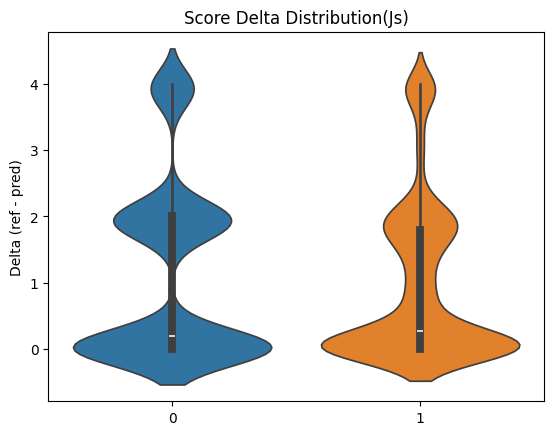

In [ ]:
with open(f"../data/humaneval-x/humaneval_js_grade_evalplus_ratio.json") as f:
    data1 = json.load(f)
with open(f"../codejudge_scripts/output/humaneval-x/js-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json") as f:
    data2 = json.load(f)

delta_total_1, delta_total_2 = compute_score_delta_v2(data1, data2["data"])

plt.figure()
sns.violinplot(data=[delta_total_1, delta_total_2])

plt.title("Score Delta Distribution(Js)")
plt.ylabel("Delta (ref - pred)")
plt.show()

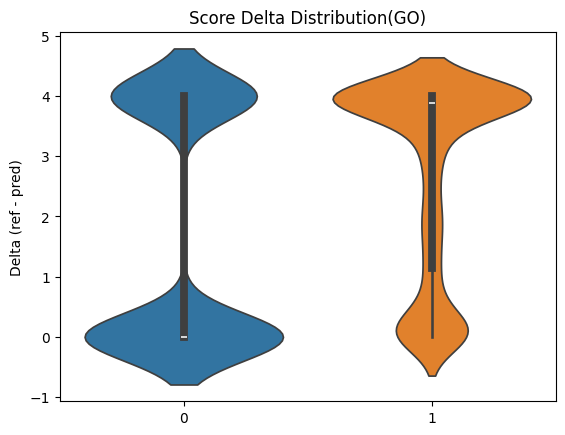

In [ ]:
with open(f"../data/humaneval-x/humaneval_go_grade_evalplus_ratio_bakj.json") as f:
    data1 = json.load(f)
with open(f"../codejudge_scripts/output/humaneval-x/go-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json") as f:
    data2 = json.load(f)

delta_total_1, delta_total_2 = compute_score_delta_v2(data1, data2["data"])

plt.figure()
sns.violinplot(data=[delta_total_1, delta_total_2])

plt.title("Score Delta Distribution(GO)")
plt.ylabel("Delta (ref - pred)")
plt.show()

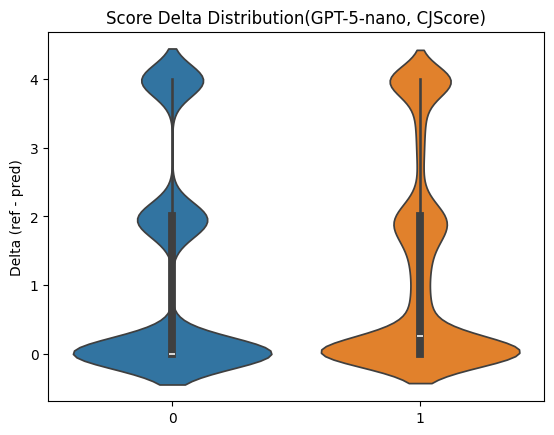

In [ ]:
file_1 = ["../data/humaneval-x/humaneval_python_grade_evalplus_ratio.json", 
          "../data/humaneval-x/humaneval_cpp_grade_evalplus_ratio.json", 
          "../data/humaneval-x/humaneval_java_grade_evalplus_ratio.json", 
          "../data/humaneval-x/humaneval_js_grade_evalplus_ratio.json", 
          "../data/humaneval-x/humaneval_go_grade_evalplus_ratio_bakj.json"]
file_2 = ["../codejudge_scripts/output/humaneval-x/python-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json", 
          "../codejudge_scripts/output/humaneval-x/cpp-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json", 
          "../codejudge_scripts/output/humaneval-x/java-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json", 
          "../codejudge_scripts/output/humaneval-x/js-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json", 
          "../codejudge_scripts/output/humaneval-x/go-small-test/ice_data/gpt-5-nano-1-4-0.0-sample-0_icedata.json"]

combined_delta_1 = []
combined_delta_2 = []

for i in range(len(file_1)):
    with open(file_1[i], "r", encoding="utf-8") as f:
        data1 = json.load(f)
    with open(file_2[i], "r", encoding="utf-8") as f:
        data2 = json.load(f)
    delta_1, delta_2 = compute_score_delta_v2(data1, data2["data"])
    combined_delta_1.extend(delta_1)
    combined_delta_2.extend(delta_2)

plt.figure()
sns.violinplot(data=[combined_delta_1, combined_delta_2])

plt.title("Score Delta Distribution(GPT-5-nano, CJScore)")
plt.ylabel("Delta (ref - pred)")
plt.show()